## Librerías.

In [1]:
import sys
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers, regularizers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.models import load_model
from tensorflow.keras import optimizers

import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')
project_path = '/content/drive/MyDrive/Redes neuronales/Tarea 7. Reconocimiento facial'
if project_path not in sys.path:
    sys.path.append(project_path)

Mounted at /content/drive


## Fine tunning.

In [3]:
# Configuramos direcciones.
data_dir = os.path.join(project_path, 'data/binary')

In [4]:
# Generadores.
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2)

# Generador de entrenamiento.
train_gen = datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=8,
    class_mode='binary',
    subset='training',
    shuffle=True)

# Generador de validación.
valid_gen = datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=8,
    class_mode='binary',
    subset='validation',
    shuffle=False)

Found 98 images belonging to 2 classes.
Found 24 images belonging to 2 classes.


In [14]:
# Cargamos modelo.
modelo_crudo = os.path.join(project_path, 'models/mi_reconocedor_pp3.h5')
model = load_model(modelo_crudo)

# Buscamos el extractor de características.
feature_extractor = None
for layer in model.layers:
    if isinstance(layer, tf.keras.Sequential):
        feature_extractor = layer
        break

if feature_extractor:
    print(f"Extractor base encontrado: {feature_extractor.name}")
    feature_extractor.trainable = True

    # Entrenamos solo las últimas capas.
    capas_a_entrenar = 3
    for layer in feature_extractor.layers[:-capas_a_entrenar]:
        layer.trainable = False

Extractor base encontrado: sequential_4


In [15]:
# Recompilamos.
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-6),
    loss='binary_crossentropy',
    metrics=['accuracy'])

ruta_final_refinado = os.path.join(project_path, 'models/mi_reconocedor_refinado_3.h5')

checkpoint_fino = ModelCheckpoint(
    filepath=ruta_final_refinado,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1)

early_stop_fino = EarlyStopping(
    monitor='val_accuracy',
    patience=30,
    restore_best_weights=True)

In [16]:
# Entrenamos.
history_fine = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=100,
    callbacks=[checkpoint_fino, early_stop_fino])

Epoch 1/100
12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - accuracy: 0.8008 - loss: 3.0024
Epoch 1: val_accuracy improved from -inf to 0.75000, saving model to /content/drive/MyDrive/Redes neuronales/Tarea 7. Reconocimiento facial/models/mi_reconocedor_refinado_3.h5


13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 447ms/step - accuracy: 0.7972 - loss: 3.0041 - val_accuracy: 0.7500 - val_loss: 3.0679
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.7624 - loss: 3.0016
Epoch 2: val_accuracy did not improve from 0.75000
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 238ms/step - accuracy: 0.7612 - loss: 3.0020 - val_accuracy: 0.7500 - val_loss: 3.0680
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.8239 - loss: 2.9802
Epoch 3: val_accuracy improved from 0.75000 to 0.79167, saving model to /content/drive/MyDrive/Redes neuronales/Tarea 7. Reconocimiento facial/models/mi_reconocedor_refinado_3.h5


13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 338ms/step - accuracy: 0.8176 - loss: 2.9825 - val_accuracy: 0.7917 - val_loss: 3.0561
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.7594 - loss: 2.9968
Epoch 4: val_accuracy did not improve from 0.79167
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 237ms/step - accuracy: 0.7576 - loss: 2.9974 - val_accuracy: 0.7083 - val_loss: 3.0593
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.7085 - loss: 3.0199
Epoch 5: val_accuracy did not improve from 0.79167
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 227ms/step - accuracy: 0.7096 - loss: 3.0189 - val_accuracy: 0.7500 - val_loss: 3.0523
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.7340 - loss: 2.9899
Epoch 6: val_accuracy did not improve from 0.79167
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 257ms/step - accuracy: 0.7348 - loss: 2.9904 - val_accuracy: 0.7083 - val_loss: 3.0541
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - accuracy: 0.6573 - loss: 3.0135
Epoch 7: val_accuracy did not i

13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 380ms/step - accuracy: 0.7741 - loss: 2.9667 - val_accuracy: 0.8333 - val_loss: 3.0101
Epoch 13/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.7728 - loss: 2.9721
Epoch 13: val_accuracy did not improve from 0.83333
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 242ms/step - accuracy: 0.7744 - loss: 2.9711 - val_accuracy: 0.7917 - val_loss: 3.0121
Epoch 14/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.7003 - loss: 2.9760
Epoch 14: val_accuracy did not improve from 0.83333
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 329ms/step - accuracy: 0.7027 - loss: 2.9753 - val_accuracy: 0.8333 - val_loss: 3.0040
Epoch 15/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.6644 - loss: 2.9761
Epoch 15: val_accuracy did not improve from 0.83333
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 288ms/step - accuracy: 0.6679 - loss: 2.9750 - val_accuracy: 0.7917 - val_loss: 3.0112
Epoch 16/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.7394 - loss: 2.9461
Epoch 16: val_accuracy d

13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 373ms/step - accuracy: 0.7584 - loss: 2.8878 - val_accuracy: 0.8750 - val_loss: 2.9475
Epoch 27/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.7734 - loss: 2.9037
Epoch 27: val_accuracy did not improve from 0.87500
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 248ms/step - accuracy: 0.7743 - loss: 2.9038 - val_accuracy: 0.7500 - val_loss: 2.9578
Epoch 28/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.7614 - loss: 2.8906
Epoch 28: val_accuracy did not improve from 0.87500
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 300ms/step - accuracy: 0.7624 - loss: 2.8904 - val_accuracy: 0.7917 - val_loss: 2.9546
Epoch 29/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.8341 - loss: 2.8858
Epoch 29: val_accuracy did not improve from 0.87500
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 314ms/step - accuracy: 0.8343 - loss: 2.8855 - val_accuracy: 0.7917 - val_loss: 2.9403
Epoch 30/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.7867 - loss: 2.8940
Epoch 30: val_accuracy d

In [17]:
def graficar_entrenamiento(historia):
    acc = historia.history['accuracy']
    val_acc = historia.history['val_accuracy']
    loss = historia.history['loss']
    val_loss = historia.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))

    # Presición.
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', color='green')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='red')
    plt.legend(loc='lower right')
    plt.title('Precisión (Accuracy)')
    plt.grid(True)
    plt.xlabel('Épocas')
    plt.ylabel('Precisión')

    # Costo.
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', color='green')
    plt.plot(epochs_range, val_loss, label='Validation Loss', color='red')
    plt.legend(loc='upper right')
    plt.title('Costo (Loss)')
    plt.grid(True)
    plt.xlabel('Épocas')
    plt.ylabel('Loss')

    plt.show()

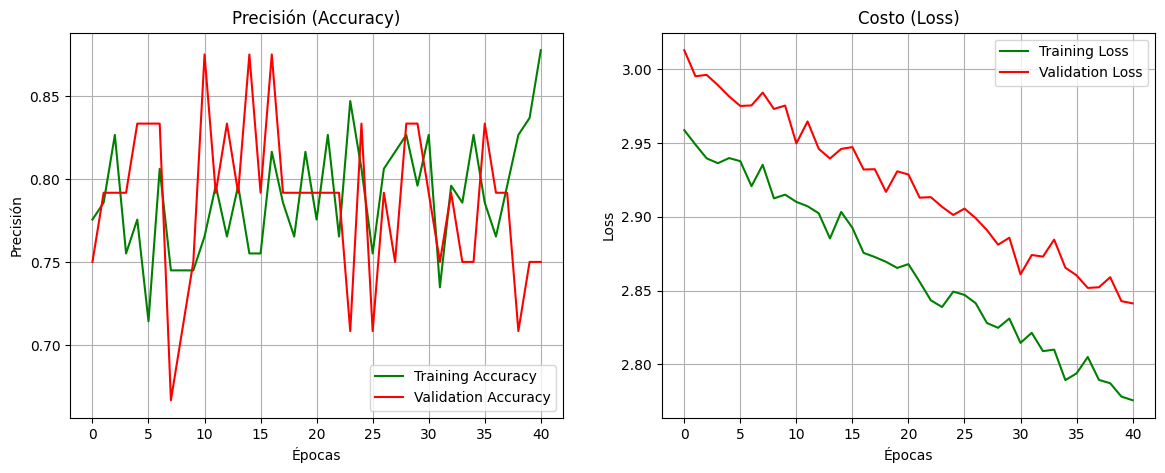

In [13]:
# Graficamos.
graficar_entrenamiento(history_fine)